# Práctica: Análisis de Emociones y Sentimiento (NLP 2025-26)

Notebook base para:
1. Construcción de dataset sintético con EmoLex + LLM
2. Entrenamiento de clasificadores no neuronales
3. Análisis emocional de novelas de Project Gutenberg

> **Pareja:** 14  
> **Fecha:** 2026-04-13

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn requests joblib python-dotenv groq

  Using cached groq-1.1.2-py3-none-any.whl.metadata (16 kB)
Using cached groq-1.1.2-py3-none-any.whl (141 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [groq]


In [2]:

import os
import re
import json
import random
import string
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import requests
import joblib
from dotenv import load_dotenv
from groq import Groq

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
FIG_DIR = Path("figures")

for d in [DATA_DIR, MODELS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EMOTIONS = ["anger", "anticipation", "disgust", "fear", "joy", "sadness", "surprise", "trust"]
POLARITY = ["negative", "positive"]


# Load .env from common candidate locations
_env_candidates = [
    Path.cwd() / '.env',
    Path('/Users/wxy/nlp/.env'),
]
for _env_path in _env_candidates:
    if _env_path.exists():
        load_dotenv(dotenv_path=_env_path, override=False)
        break


## 1) Carga del NRC EmoLex

Descarga manualmente el archivo de EmoLex y colócalo, por ejemplo, en:
- `data/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt`

Formato esperado por línea: `word\temotion\tassociation`

In [3]:
def load_emolex(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None, names=["word", "emotion", "association"])
    df = df[df["association"] == 1].copy()
    return df


def build_seed_table(emolex_df: pd.DataFrame) -> pd.DataFrame:
    grouped = emolex_df.groupby("word")["emotion"].apply(list).reset_index()

    def split_labels(labels):
        emo = sorted([x for x in labels if x in EMOTIONS])
        pol = sorted([x for x in labels if x in POLARITY])
        return emo, pol

    out = grouped.copy()
    out[["emotion_labels", "polarity_labels"]] = out["emotion"].apply(lambda x: pd.Series(split_labels(x)))
    out = out.drop(columns=["emotion"])
    return out

path = DATA_DIR / "NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"
emolex = load_emolex(path)
seeds = build_seed_table(emolex)
seeds.head()

,word,emotion_labels,polarity_labels
0,abacus,[trust],[]
1,abandon,"[fear, sadness]",[negative]
2,abandoned,"[anger, fear, sadness]",[negative]
3,abandonment,"[anger, fear, sadness, surprise]",[negative]
4,abba,[],[positive]


## 2) Dataset sintético con LLM

Para generar el dataset sintético se utilizó **Groq** con el modelo **`llama-3.1-8b-instant`**. La generación se apoyó en las palabras semilla del NRC EmoLex y se orientó a producir frases en **inglés**, ya que las novelas analizadas posteriormente también están en ese idioma. Así se reduce el desajuste entre el dominio de entrenamiento y el de aplicación.

La estrategia fue **controlada por emoción**: en cada llamada al LLM se fijó una emoción objetivo y se envió un pequeño lote de palabras semilla asociadas a dicha emoción. Además, se impusieron restricciones para mejorar la calidad del conjunto de datos: frases de 10 a 20 palabras, inclusión explícita de la palabra semilla o una variante morfológica clara, ausencia de nombres propios, sarcasmo o tecnicismos, y una única emoción dominante por frase.

El prompt exacto empleado es el que aparece parametrizado en la celda siguiente mediante `PROMPT_BATCH_TEMPLATE`. Se probaron varias versiones preliminares y finalmente se adoptó la versión `v2-batch`, porque devolvía con más estabilidad un JSON válido y reducía el número de peticiones al agrupar varias semillas por llamada.

Cada fila del dataset conserva información útil para la trazabilidad del proceso: `seed_word`, etiquetas emocionales y de polaridad procedentes de EmoLex, emoción principal (`primary_emotion`), frase generada, modelo utilizado, versión del prompt y ronda de generación. Después de generar los datos se realizó una fase de limpieza para eliminar frases vacías, controlar la longitud y suprimir duplicados normalizados.

En la ejecución mostrada, el dataset final contiene **480 ejemplos**, con **60 frases por emoción**, sin duplicados normalizados y con una longitud media de **14.41 palabras**. La distribución de clases es completamente balanceada porque el muestreo de semillas y el número de frases por semilla se fijaron de forma simétrica. Esto es útil para entrenar clasificadores y para comparar modelos sin introducir sesgos fuertes hacia emociones mayoritarias.

Aun así, el tamaño del dataset debe interpretarse con cautela: para una práctica docente es suficiente para entrenar y comparar modelos clásicos, pero probablemente no basta para cubrir toda la variedad léxica, semántica y estilística de textos literarios reales. Si el dataset hubiera quedado desbalanceado, una solución razonable habría sido generar más ejemplos para las clases minoritarias, submuestrear las mayoritarias o ajustar pesos de clase durante el entrenamiento.

Por último, es recomendable revisar manualmente una muestra de frases generadas para comprobar que la emoción dominante es coherente y que no se han introducido patrones artificiales demasiado evidentes. Esta validación cualitativa es importante porque la fiabilidad del resto de tareas depende directamente de la calidad del dataset sintético.

### 2.1 Generacion automatica de dataset sintetico desde EmoLex

Configura tu API key en `.env`:

```bash
GROQ_API_KEY=tu_api_key_aqui
```

Este bloque usa **Groq** con **varias palabras semilla por llamada API** (menos requests, mismo volumen de datos).

In [4]:
import ast
import time

TARGET_EMOTIONS = ["anger", "anticipation", "disgust", "fear", "joy", "sadness", "surprise", "trust"]
PROMPT_VERSION = "v2-batch"

# Varias semillas por una sola llamada (misma emocion por batch)
PROMPT_BATCH_TEMPLATE = """You are generating synthetic training data for emotion classification.

Target emotion (ALL items below must use ONLY this emotion): {emotion}

For EACH seed word listed, generate exactly {n_sentences} English sentences (separate strings in the array).

Global rules:
1) Each sentence: 10-20 words.
2) Dominant emotion must be ONLY '{emotion}'.
3) Each sentence must clearly include its seed word (or a clear morphological variant).
4) Avoid proper nouns, sarcasm, heavy metaphor, technical jargon.
5) No duplicate sentences within the same seed.

Seed words (generate in this exact order):
{seed_lines}

Return JSON ONLY. Must be a JSON array with one object per seed, SAME ORDER as above:
[
  {{"seed_word": "word1", "sentences": ["...", "..."]}},
  {{"seed_word": "word2", "sentences": ["...", "..."]}}
]
"""


def parse_label_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()
    if not s:
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(i) for i in v]
    except Exception:
        pass
    return [i.strip() for i in s.split(',') if i.strip()]


def build_seed_pool(seed_df: pd.DataFrame, n_per_emotion: int = 80, min_len: int = 3) -> dict:
    tmp = seed_df.copy()
    tmp['word'] = tmp['word'].astype(str).str.lower()
    tmp = tmp[tmp['word'].str.match(r"^[a-z][a-z'\-]*$", na=False)]
    tmp = tmp[tmp['word'].str.len() >= min_len]

    if 'emotion_labels' in tmp.columns:
        tmp['emotion_labels'] = tmp['emotion_labels'].apply(parse_label_list)

    pool = {}
    for emo in TARGET_EMOTIONS:
        if 'emotion_labels' in tmp.columns:
            words = sorted(tmp[tmp['emotion_labels'].apply(lambda labels: emo in labels)]['word'].unique().tolist())
        else:
            words = sorted(tmp[tmp['emotion'] == emo]['word'].unique().tolist())

        if len(words) <= n_per_emotion:
            selected = words
        else:
            selected = random.sample(words, n_per_emotion)
        pool[emo] = selected
    return pool


def _chunks(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i + size]


In [5]:
from pathlib import Path
import json
import pandas as pd

def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def safe_read_csv(path: Path, **kwargs) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path, **kwargs)
    return pd.DataFrame()

def save_json(obj, path: Path):
    ensure_dir(path.parent)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=True, indent=2)

def load_json(path: Path, default=None):
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def plot_class_distribution(df: pd.DataFrame, title="Distribucion de clases"):
    plt.figure(figsize=(8, 4))
    order = sorted(df["primary_emotion"].unique())
    sns.countplot(data=df, x="primary_emotion", order=order)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = s.translate(str.maketrans("", "", string.punctuation))
    return s


In [6]:
def call_groq_chat(prompt: str, model: str = "llama-3.1-8b-instant", timeout: int = 120) -> str:
    api_key = os.getenv("GROQ_API_KEY")
    if not api_key:
        raise ValueError("GROQ_API_KEY no esta definido. Anade GROQ_API_KEY en .env y reinicia el kernel.")

    client = Groq(api_key=api_key)
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You create high-quality synthetic NLP datasets. Always follow JSON output rules exactly."},
            {"role": "user", "content": prompt},
        ],
        temperature=0.7,
        max_completion_tokens=4096,
        stream=False,
    )
    return completion.choices[0].message.content


def parse_llm_json(raw_text: str):
    raw_text = raw_text.strip()
    try:
        return json.loads(raw_text)
    except Exception:
        pass
    m = re.search(r"\[.*\]", raw_text, flags=re.DOTALL)
    if m:
        try:
            return json.loads(m.group(0))
        except Exception:
            return None
    return None


def merge_emotion_raw_files(checkpoint_dir: Path, emotions=EMOTIONS) -> pd.DataFrame:
    frames = []
    for emotion in emotions:
        rows_path = checkpoint_dir / f"raw_{emotion}.csv"
        if rows_path.exists():
            frames.append(pd.read_csv(rows_path))
    if not frames:
        return pd.DataFrame()
    merged = pd.concat(frames, ignore_index=True)
    merged["id"] = np.arange(len(merged))
    return merged


def generate_synthetic_dataset(
    seed_pool: dict,
    seeds_df: pd.DataFrame,
    llm_model: str = "llama-3.1-8b-instant",
    n_sentences_per_seed: int = 2,
    seeds_per_api_call: int = 5,
    max_retries: int = 3,
    sleep_sec: float = 0.6,
    checkpoint_dir: Path = DATA_DIR / "synthetic_checkpoints",
    resume: bool = True,
) -> pd.DataFrame:
    """Varias semillas por llamada Groq (menos API calls). Checkpoint por emocion + seed individual."""
    ensure_dir(checkpoint_dir)

    seed_meta = seeds_df.copy()
    seed_meta["word"] = seed_meta["word"].astype(str).str.lower()
    if "emotion_labels" in seed_meta.columns:
        seed_meta["emotion_labels"] = seed_meta["emotion_labels"].apply(parse_label_list)
    if "polarity_labels" in seed_meta.columns:
        seed_meta["polarity_labels"] = seed_meta["polarity_labels"].apply(parse_label_list)
    seed_meta = seed_meta.drop_duplicates(subset=["word"]).set_index("word")

    for emotion, words in seed_pool.items():
        rows_path = checkpoint_dir / f"raw_{emotion}.csv"
        processed_path = checkpoint_dir / f"processed_seeds_{emotion}.json"

        existing_rows = safe_read_csv(rows_path)
        rows = existing_rows.to_dict(orient="records") if not existing_rows.empty else []
        processed = set(load_json(processed_path, default=[])) if resume else set()

        idx = len(rows)
        pending = [w for w in words if f"{emotion}::{w}" not in processed]

        for batch in _chunks(pending, max(1, int(seeds_per_api_call))):
            seed_lines = "\n".join(f"- {w}" for w in batch)
            prompt = PROMPT_BATCH_TEMPLATE.format(
                emotion=emotion,
                n_sentences=n_sentences_per_seed,
                seed_lines=seed_lines,
            )

            parsed = None
            last_err = None
            for _ in range(max_retries):
                try:
                    raw = call_groq_chat(prompt, model=llm_model)
                    parsed = parse_llm_json(raw)
                    if isinstance(parsed, list) and len(parsed) > 0:
                        break
                except Exception as e:
                    last_err = str(e)
                time.sleep(sleep_sec)

            if not isinstance(parsed, list):
                print(f"[WARN] Batch failed emotion={emotion} seeds={batch} err={last_err}")
                time.sleep(sleep_sec)
                continue

            by_seed = {}
            for item in parsed:
                if not isinstance(item, dict):
                    continue
                sw = str(item.get("seed_word", "")).strip().lower()
                sents = item.get("sentences")
                if isinstance(sents, str):
                    sents = [sents]
                if not isinstance(sents, list):
                    sents = []
                sents = [str(s).strip() for s in sents if str(s).strip()]
                if sw:
                    by_seed[sw] = sents

            batch_ok = True
            for seed_word in batch:
                key = f"{emotion}::{seed_word}"
                sents = by_seed.get(seed_word.lower(), [])
                if len(sents) < n_sentences_per_seed:
                    batch_ok = False
                    print(f"[WARN] Missing/short output seed={seed_word} emotion={emotion} got={len(sents)}")
                    continue

                emo_labels = []
                pol_labels = []
                if seed_word in seed_meta.index:
                    if "emotion_labels" in seed_meta.columns:
                        emo_labels = seed_meta.loc[seed_word, "emotion_labels"]
                    if "polarity_labels" in seed_meta.columns:
                        pol_labels = seed_meta.loc[seed_word, "polarity_labels"]

                for sent in sents[:n_sentences_per_seed]:
                    rows.append({
                        "id": idx,
                        "seed_word": seed_word,
                        "emotion_labels": emo_labels,
                        "polarity_labels": pol_labels,
                        "primary_emotion": emotion,
                        "generated_sentence": sent,
                        "language": "en",
                        "llm_model": llm_model,
                        "prompt_version": PROMPT_VERSION,
                        "generation_round": 1,
                    })
                    idx += 1

                processed.add(key)

            pd.DataFrame(rows).to_csv(rows_path, index=False)
            save_json(sorted(list(processed)), processed_path)
            if batch_ok:
                print(f"[CKPT][{emotion}] batch_seeds={len(batch)} rows={len(rows)} api_batches_done")
            time.sleep(sleep_sec)

        print(f"[DONE][{emotion}] rows={len(rows)} processed={len(processed)}")

    merged = merge_emotion_raw_files(checkpoint_dir)
    print(f"[MERGED] rows={len(merged)} from per-emotion files")
    return merged


[CKPT][anger] batch_seeds=5 rows=10 api_batches_done
[CKPT][anger] batch_seeds=5 rows=20 api_batches_done
[CKPT][anger] batch_seeds=5 rows=30 api_batches_done
[CKPT][anger] batch_seeds=5 rows=40 api_batches_done
[CKPT][anger] batch_seeds=5 rows=50 api_batches_done
[CKPT][anger] batch_seeds=5 rows=60 api_batches_done
[DONE][anger] rows=60 processed=30
[CKPT][anticipation] batch_seeds=5 rows=10 api_batches_done
[CKPT][anticipation] batch_seeds=5 rows=20 api_batches_done
[CKPT][anticipation] batch_seeds=5 rows=30 api_batches_done
[CKPT][anticipation] batch_seeds=5 rows=40 api_batches_done
[CKPT][anticipation] batch_seeds=5 rows=50 api_batches_done
[CKPT][anticipation] batch_seeds=5 rows=60 api_batches_done
[DONE][anticipation] rows=60 processed=30
[CKPT][disgust] batch_seeds=5 rows=10 api_batches_done
[CKPT][disgust] batch_seeds=5 rows=20 api_batches_done
[CKPT][disgust] batch_seeds=5 rows=30 api_batches_done
[CKPT][disgust] batch_seeds=5 rows=40 api_batches_done
[CKPT][disgust] batch_see

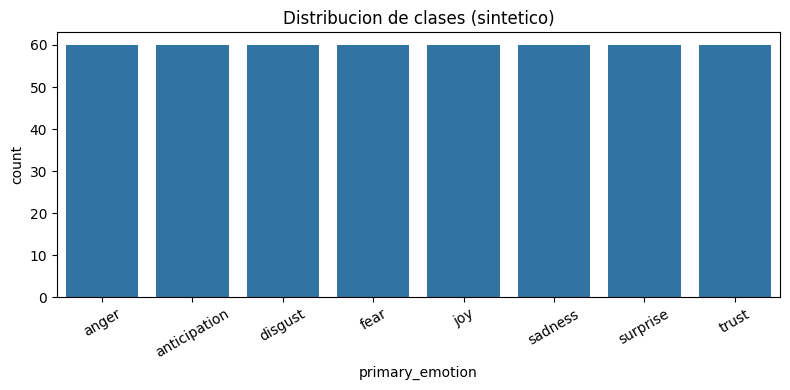

In [7]:
def clean_synthetic_dataset(df: pd.DataFrame, min_words: int = 6, max_words: int = 35) -> pd.DataFrame:
    out = df.copy()
    out['generated_sentence'] = out['generated_sentence'].astype(str).str.strip()
    out = out[out['generated_sentence'] != '']

    out['n_words'] = out['generated_sentence'].apply(lambda s: len(s.split()))
    out = out[(out['n_words'] >= min_words) & (out['n_words'] <= max_words)]

    out['norm_sentence'] = out['generated_sentence'].apply(normalize_text)
    out = out.drop_duplicates(subset=['primary_emotion', 'norm_sentence'])

    out['emotion_labels'] = out['emotion_labels'].apply(lambda x: json.dumps(x, ensure_ascii=True))
    out['polarity_labels'] = out['polarity_labels'].apply(lambda x: json.dumps(x, ensure_ascii=True))

    out = out.drop(columns=['norm_sentence']).reset_index(drop=True)
    out['id'] = np.arange(len(out))
    return out


def quick_dataset_report(df: pd.DataFrame):
    print(f"n_samples = {len(df)}")
    print(f"avg_sentence_len = {df['generated_sentence'].str.split().str.len().mean():.2f}")
    print("class_distribution:")
    print(df['primary_emotion'].value_counts().sort_index())
    dup = df['generated_sentence'].astype(str).apply(normalize_text).duplicated().mean()
    print(f"duplicate_ratio = {dup:.4f}")


# Paso 1: pool de seeds (ajusta n_per_emotion si hace falta)
seed_pool = build_seed_pool(seeds, n_per_emotion=30)

# Paso 2: Groq — varias semillas por llamada (seeds_per_api_call)
raw_synth = generate_synthetic_dataset(
    seed_pool=seed_pool,
    seeds_df=seeds,
    llm_model="llama-3.1-8b-instant",
    n_sentences_per_seed=2,
    seeds_per_api_call=5,
    max_retries=3,
    resume=True,
)

# Paso 3: limpiar + exportar
synth = clean_synthetic_dataset(raw_synth)
out_path = DATA_DIR / "synthetic_emotion_dataset.csv"
synth.to_csv(out_path, index=False)
print(f"Dataset guardado en: {out_path}")
quick_dataset_report(synth)
plot_class_distribution(synth, title="Distribucion de clases (sintetico)")


### 2.2 Diagnóstico del dataset ya generado

En esta celda se carga el CSV final y se comprueban varias cuestiones pedidas en el enunciado: tamaño del dataset, longitud media de las frases, existencia de duplicados y distribución de clases. En la ejecución mostrada se obtiene un dataset **balanceado** con **480 ejemplos**, sin duplicados normalizados y con una longitud media adecuada para entrenar clasificadores clásicos sobre texto breve.

{'n_samples': 480, 'dup_ratio': 0.0, 'avg_sentence_len': 14.40625, 'class_dist': primary_emotion
anger           0.125
anticipation    0.125
disgust         0.125
fear            0.125
joy             0.125
sadness         0.125
surprise        0.125
trust           0.125
Name: proportion, dtype: float64}


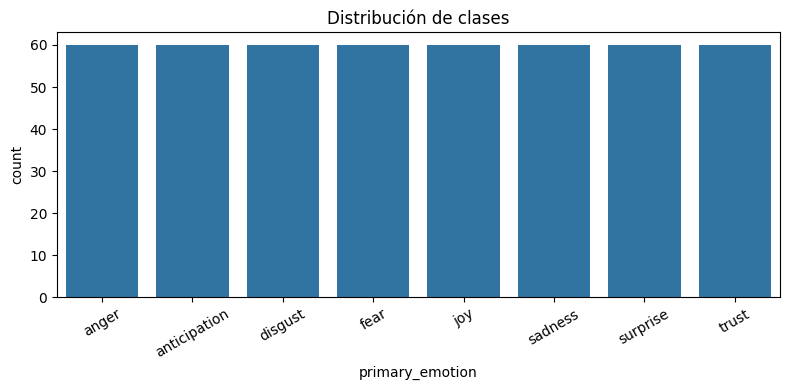

In [15]:
SYNTH_COLS = [
    "id", "seed_word", "emotion_labels", "polarity_labels", "primary_emotion",
    "generated_sentence", "language", "llm_model", "prompt_version", "generation_round"
]


def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = s.translate(str.maketrans("", "", string.punctuation))
    return s


def load_synthetic_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    missing = [c for c in SYNTH_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el dataset: {missing}")
    return df


def dataset_diagnostics(df: pd.DataFrame) -> dict:
    tmp = df.copy()
    tmp["norm_sentence"] = tmp["generated_sentence"].astype(str).apply(normalize_text)
    dup_ratio = tmp["norm_sentence"].duplicated().mean()
    avg_len = tmp["generated_sentence"].astype(str).apply(lambda x: len(x.split())).mean()

    class_dist = tmp["primary_emotion"].value_counts(normalize=True).sort_index()

    return {
        "n_samples": len(tmp),
        "dup_ratio": float(dup_ratio),
        "avg_sentence_len": float(avg_len),
        "class_dist": class_dist,
    }


def plot_class_distribution(df: pd.DataFrame, title="Distribución de clases"):
    plt.figure(figsize=(8, 4))
    order = sorted(df["primary_emotion"].unique())
    sns.countplot(data=df, x="primary_emotion", order=order)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

synth = load_synthetic_dataset(DATA_DIR / "synthetic_emotion_dataset.csv")
info = dataset_diagnostics(synth)
print(info)
plot_class_distribution(synth)

## 3) Entrenamiento y evaluación (2 algoritmos × 2 vectorizadores)

Para esta práctica se adopta un enfoque de **clasificación monolabel** usando `primary_emotion` como variable objetivo. Aunque EmoLex admite asociaciones múltiples, esta simplificación facilita comparar algoritmos clásicos y construir un pipeline de análisis más estable.

Se entrenan **dos algoritmos no basados en redes neuronales**: `LogisticRegression` y `LinearSVC`. Ambos son buenas baselines en clasificación de texto porque funcionan bien con representaciones dispersas, son eficientes y suelen ofrecer resultados competitivos en tareas con pocos datos. Para vectorizar el texto se prueban varias alternativas: `TF-IDF`, `CountVectorizer` y `HashingVectorizer`, que representan tres enfoques habituales en PLN clásico.

La política de partición es `70%` para entrenamiento, `15%` para validación y `15%` para test, usando división estratificada para mantener el equilibrio entre emociones. La selección del mejor modelo se realiza con validación, y el conjunto de test se reserva para la evaluación final. Como métricas principales se utilizan **accuracy** y **macro-F1**; esta última es especialmente adecuada en clasificación multiclase porque considera por igual todas las emociones.

En los resultados obtenidos, la mejor combinación es **Logistic Regression + TF-IDF**, con una `macro-F1` de aproximadamente **0.507** en validación. El rendimiento es moderado, algo esperable porque el conjunto es sintético y relativamente pequeño, pero suficiente para continuar con el análisis de novelas.

In [16]:
def build_vectorizers():
    return {
        "tfidf": TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000),
        "count": CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000),
        "hashing": HashingVectorizer(ngram_range=(1, 2), n_features=2**18, alternate_sign=False),
    }


def build_models():
    return {
        "logreg": LogisticRegression(max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE),
        "linearsvc": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    }


def split_data(df: pd.DataFrame):
    X = df["generated_sentence"].astype(str).values
    y = df["primary_emotion"].astype(str).values

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def train_and_evaluate(X_train, y_train, X_val, y_val, model_name, vectorizer_name):
    vec = build_vectorizers()[vectorizer_name]
    model = build_models()[model_name]

    pipe = Pipeline([
        ("vectorizer", vec),
        ("clf", model),
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)

    metrics = {
        "accuracy": accuracy_score(y_val, pred),
        "macro_f1": f1_score(y_val, pred, average="macro"),
        "report": classification_report(y_val, pred, output_dict=True),
    }
    return pipe, metrics


def run_experiments(df: pd.DataFrame):
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

    configs = [
        ("logreg", "tfidf"),
        ("logreg", "count"),
        ("linearsvc", "tfidf"),
        ("linearsvc", "hashing"),
    ]

    trained = {}
    rows = []

    for m, v in configs:
        pipe, met = train_and_evaluate(X_train, y_train, X_val, y_val, m, v)
        key = f"{m}_{v}"
        trained[key] = pipe
        rows.append({"model": m, "vectorizer": v, "val_accuracy": met["accuracy"], "val_macro_f1": met["macro_f1"]})

    results_df = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)
    return trained, results_df, (X_train, X_val, X_test, y_train, y_val, y_test)


def final_test_evaluation(best_pipe, X_test, y_test):
    pred = best_pipe.predict(X_test)
    print(classification_report(y_test, pred))
    cm = confusion_matrix(y_test, pred, labels=sorted(np.unique(y_test)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title("Matriz de confusión (test)")
    plt.tight_layout()
    plt.show()

trained_models, results_table, splits = run_experiments(synth)
display(results_table)

# Clave del mejor pipeline (debe coincidir con trained_models)
best_row = results_table.iloc[0]
best_model_name = f"{best_row['model']}_{best_row['vectorizer']}"
print("Mejor combinacion (val macro F1):", best_model_name)

X_train, X_val, X_test, y_train, y_val, y_test = splits
final_test_evaluation(trained_models[best_model_name], X_test, y_test)


,model,vectorizer,val_accuracy,val_macro_f1
0,logreg,tfidf,0.513889,0.507390
2,linearsvc,tfidf,0.500000,0.499507
3,linearsvc,hashing,0.500000,0.489822
1,logreg,count,0.472222,0.467873


{'model': 'logreg', 'vectorizer': 'tfidf', 'val_accuracy': 0.5138888888888888, 'val_macro_f1': 0.5073904166009429}


In [18]:
def save_pipeline(pipe, name: str):
    out = MODELS_DIR / f"{name}.joblib"
    joblib.dump(pipe, out)
    return out


def load_pipeline(name: str):
    return joblib.load(MODELS_DIR / f"{name}.joblib")

best_model_name = results_table.iloc[0]["model"] + "_" + results_table.iloc[0]["vectorizer"]
save_pipeline(trained_models[best_model_name], best_model_name)

PosixPath('models/logreg_tfidf.joblib')

## 4) Función de análisis emocional sobre texto libre

La función de esta sección recibe un texto arbitrario y uno de los clasificadores entrenados. Para tratar documentos largos, el texto se divide primero en bloques de tamaño fijo. Después se calcula un perfil emocional por bloque y se agrega un perfil global para el documento completo.

La estrategia elegida para decidir el **nivel de cada emoción** es la siguiente: si el clasificador dispone de probabilidades (`predict_proba`), se toma la **media de probabilidades por emoción** en todos los bloques; si no dispone de probabilidades, se usa la **frecuencia relativa de predicciones**. De esta manera se obtiene una salida continua y comparable entre textos de distinta longitud.

In [19]:
def split_into_blocks(text: str, block_size_words: int = 160):
    words = text.split()
    blocks = []
    for i in range(0, len(words), block_size_words):
        block = " ".join(words[i:i + block_size_words]).strip()
        if block:
            blocks.append(block)
    return blocks


def emotion_profile_for_text(text: str, pipe, emotions=EMOTIONS, block_size_words: int = 160):
    blocks = split_into_blocks(text, block_size_words=block_size_words)
    if not blocks:
        return {e: 0.0 for e in emotions}

    clf = pipe.named_steps["clf"]
    preds = pipe.predict(blocks)

    # Si el modelo ofrece probabilidades, se promedian por bloque; si no,
    # se usa la frecuencia relativa de las etiquetas predichas.
    if hasattr(clf, "predict_proba"):
        proba = pipe.predict_proba(blocks)
        labels = list(pipe.classes_)
        prof = {e: 0.0 for e in emotions}
        for j, label in enumerate(labels):
            if label in prof:
                prof[label] = float(np.mean(proba[:, j]))
        return prof

    counts = Counter(preds)
    total = len(preds)
    return {e: counts.get(e, 0) / total for e in emotions}
# --- Demo Tarea 3 (ejecutar DESPUES de la celda con run_experiments) ---
if "trained_models" not in globals() or "results_table" not in globals():
    raise RuntimeError(
        "Falta entrenar: ejecuta antes la celda que hace run_experiments(synth) "
        "y define trained_models / results_table."
    )
if "best_model_name" not in globals():
    _br = results_table.iloc[0]
    best_model_name = f"{_br['model']}_{_br['vectorizer']}"

pipe_demo = trained_models[best_model_name]
profile = emotion_profile_for_text("I feel afraid but hopeful today", pipe_demo)
print("modelo:", best_model_name)
print(profile)


modelo: logreg_tfidf
{'anger': 0.11772550478232821, 'anticipation': 0.08606761630894921, 'disgust': 0.1559094260776485, 'fear': 0.1286291080717227, 'joy': 0.09007058954425903, 'sadness': 0.17887858807308168, 'surprise': 0.10985173255863083, 'trust': 0.13286743458337982}


## 5) Descarga y análisis de novelas de Project Gutenberg

Para organizar los resultados se utiliza un **diccionario indexado por título**. Cada entrada almacena la `url` original, el número de bloques analizados, el perfil emocional global y un `DataFrame` con el detalle por bloque. Esta estructura permite acceder de forma sencilla tanto al resumen de cada novela como a la información necesaria para las visualizaciones y comparaciones posteriores.

El flujo seguido es: descarga automática del texto, limpieza de cabecera y pie estándar de Project Gutenberg, segmentación en bloques, aplicación de la función de análisis emocional sobre cada bloque y cálculo de un perfil global por novela. En la ejecución mostrada se procesan **cinco novelas**, cumpliendo el mínimo exigido en el enunciado.

In [20]:
books = {
    "Crime and Punishment": "http://www.gutenberg.org/files/2554/2554-0.txt",
    "War and Peace": "http://www.gutenberg.org/files/2600/2600-0.txt",
    "Pride and Prejudice": "http://www.gutenberg.org/files/1342/1342-0.txt",
    "Frankenstein": "https://www.gutenberg.org/cache/epub/84/pg84.txt",
    "The Adventures of Sherlock Holmes": "http://www.gutenberg.org/files/1661/1661-0.txt",
    "Moby Dick": "http://www.gutenberg.org/files/15/15-0.txt",
}


def download_text(url: str):
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        return r.text
    except requests.RequestException as e:
        print(f"Error al descargar {url}: {e}")
        return None


def strip_gutenberg_header_footer(text: str) -> str:
    if not text:
        return ""

    start_patterns = [
        r"\*\*\* START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
        r"\*\*\*START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
    ]
    end_patterns = [
        r"\*\*\* END OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
        r"\*\*\*END OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
    ]

    start_idx = 0
    for p in start_patterns:
        m = re.search(p, text, flags=re.IGNORECASE | re.DOTALL)
        if m:
            start_idx = m.end()
            break

    end_idx = len(text)
    for p in end_patterns:
        m = re.search(p, text, flags=re.IGNORECASE | re.DOTALL)
        if m:
            end_idx = m.start()
            break

    cleaned = text[start_idx:end_idx]
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned


def analyze_books(book_dict: dict, pipe, n_books: int = 5, block_size_words: int = 160):
    results = {}
    selected = list(book_dict.items())[:n_books]

    for title, url in selected:
        raw = download_text(url)
        if not raw:
            continue
        cleaned = strip_gutenberg_header_footer(raw)
        blocks = split_into_blocks(cleaned, block_size_words=block_size_words)

        block_profiles = []
        for i, b in enumerate(blocks):
            prof = emotion_profile_for_text(b, pipe, block_size_words=block_size_words)
            block_profiles.append({"block_id": i, "text": b, **prof})

        block_df = pd.DataFrame(block_profiles)
        global_profile = block_df[EMOTIONS].mean().to_dict() if not block_df.empty else {e: 0.0 for e in EMOTIONS}

        results[title] = {
            "url": url,
            "n_blocks": len(blocks),
            "global_profile": global_profile,
            "blocks_df": block_df,
        }

    return results

book_results = analyze_books(books, trained_models[best_model_name], n_books=5)
list(book_results.keys())

['Crime and Punishment',
 'War and Peace',
 'Pride and Prejudice',
 'Frankenstein',
 'The Adventures of Sherlock Holmes']

,book,anger,anticipation,disgust,fear,joy,sadness,surprise,trust
0,Crime and Punishment,0.130287,0.123483,0.102292,0.142802,0.113060,0.148271,0.098063,0.141742
1,War and Peace,0.141880,0.128450,0.116028,0.143548,0.120712,0.131291,0.094953,0.123139
2,Pride and Prejudice,0.133447,0.121802,0.095589,0.153477,0.119927,0.139929,0.090667,0.145163
3,Frankenstein,0.123221,0.116904,0.119619,0.145237,0.104225,0.179185,0.095546,0.116063
4,The Adventures of Sherlock Holmes,0.134498,0.139933,0.113442,0.142667,0.108617,0.140507,0.094539,0.125797


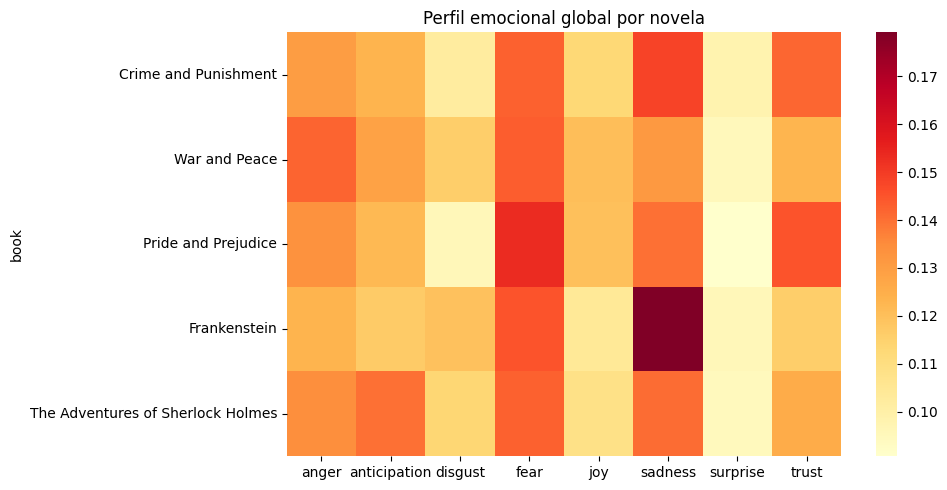

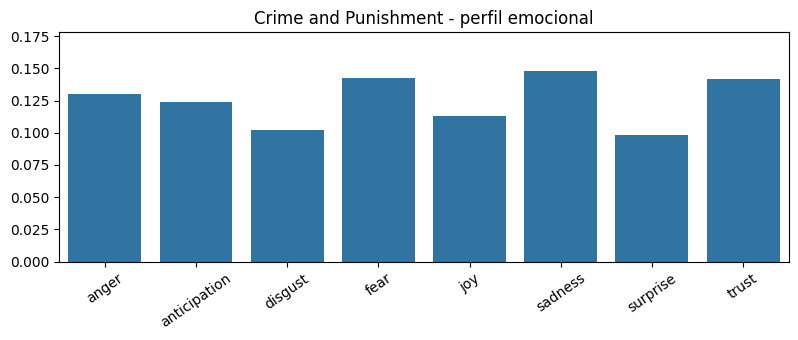

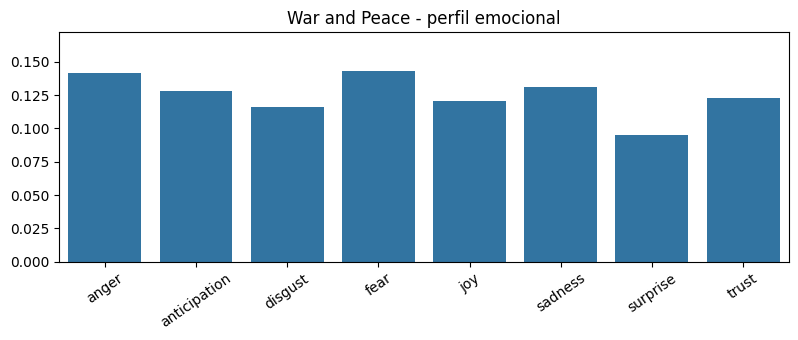

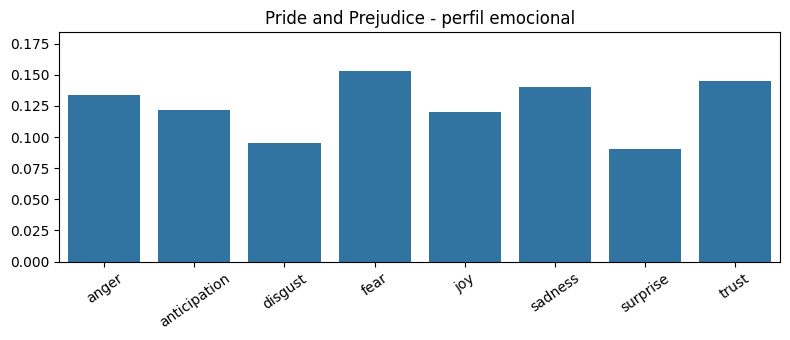

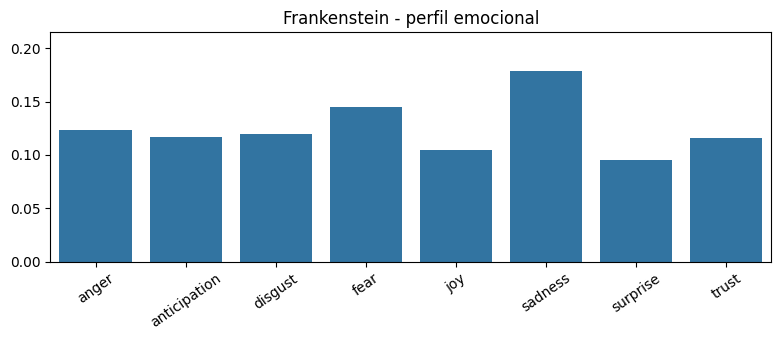

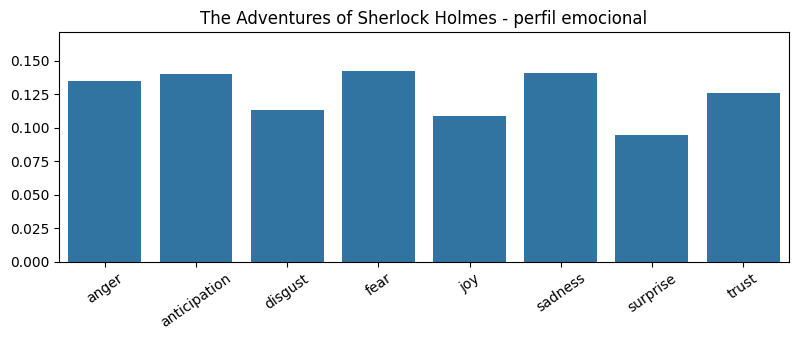

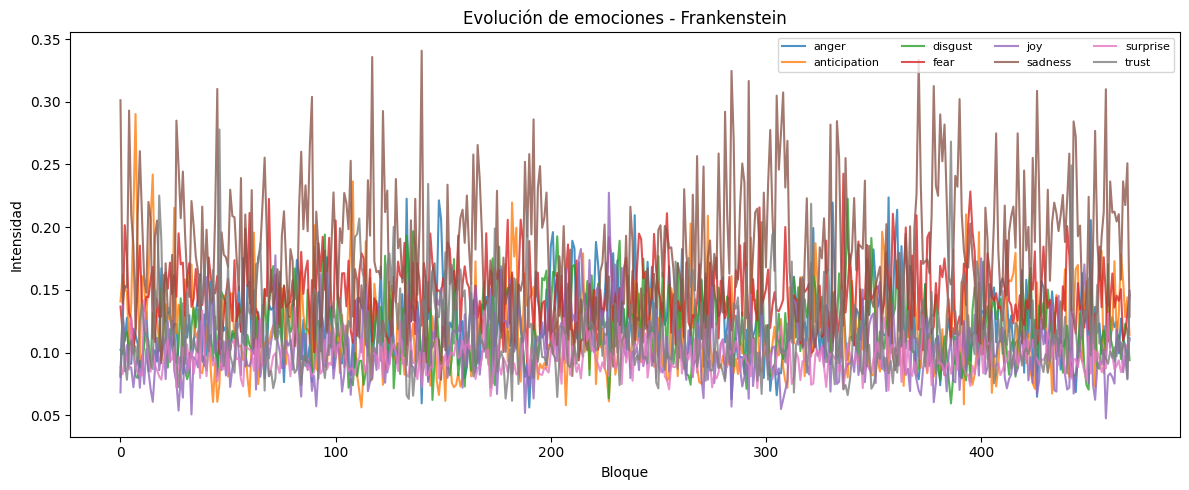

In [21]:
def global_profile_table(book_results: dict) -> pd.DataFrame:
    rows = []
    for title, obj in book_results.items():
        row = {"book": title, **obj["global_profile"]}
        rows.append(row)
    if not rows:
        return pd.DataFrame(columns=["book"] + EMOTIONS)
    return pd.DataFrame(rows)


def plot_book_profiles(df_profiles: pd.DataFrame):
    if df_profiles.empty:
        print("No hay resultados para visualizar.")
        return

    # Heatmap
    plt.figure(figsize=(10, 5))
    heat = df_profiles.set_index("book")[EMOTIONS]
    sns.heatmap(heat, cmap="YlOrRd", annot=False)
    plt.title("Perfil emocional global por novela")
    plt.tight_layout()
    plt.show()

    # Barras por novela
    for _, row in df_profiles.iterrows():
        plt.figure(figsize=(8, 3.5))
        vals = [row[e] for e in EMOTIONS]
        sns.barplot(x=EMOTIONS, y=vals)
        plt.xticks(rotation=35)
        plt.ylim(0, max(vals) * 1.2 if max(vals) > 0 else 1)
        plt.title(f"{row['book']} - perfil emocional")
        plt.tight_layout()
        plt.show()


def plot_emotion_timeline(book_results: dict, book_name: str):
    if book_name not in book_results:
        print(f"{book_name} no encontrado")
        return
    df = book_results[book_name]["blocks_df"]
    if df.empty:
        print("Sin bloques para esta novela")
        return

    plt.figure(figsize=(12, 5))
    for emo in EMOTIONS:
        plt.plot(df["block_id"], df[emo], label=emo, alpha=0.8)
    plt.title(f"Evolución de emociones - {book_name}")
    plt.xlabel("Bloque")
    plt.ylabel("Intensidad")
    plt.legend(ncol=4, fontsize=8)
    plt.tight_layout()
    plt.show()

profiles_df = global_profile_table(book_results)
display(profiles_df)
plot_book_profiles(profiles_df)
plot_emotion_timeline(book_results, "Frankenstein")

## 6) Discusión crítica y conclusiones

El análisis global de las novelas ofrece perfiles razonables, aunque las diferencias entre obras no son extremas. En los resultados obtenidos, **`sadness`** aparece como emoción especialmente destacada en *Frankenstein*, algo coherente con el tono trágico y sombrío de la obra. En *Crime and Punishment* también sobresalen `fear` y `sadness`, mientras que en *Pride and Prejudice* y *The Adventures of Sherlock Holmes* el perfil está más repartido entre `trust`, `fear` y `anticipation`. En conjunto, el sistema parece capturar parcialmente el tono general de cada novela, aunque con un nivel de separación moderado.

Las visualizaciones elegidas cubren distintos niveles de análisis: la tabla resume el perfil global por obra, el **heatmap** facilita la comparación entre novelas, los gráficos de barras muestran con más detalle el peso relativo de cada emoción y la serie temporal por bloques permite observar la evolución interna de una novela. En esta práctica se ilustra esa evolución con *Frankenstein*.

Sin embargo, el enfoque presenta limitaciones importantes. La primera es la **fiabilidad limitada del entrenamiento con datos sintéticos**: aunque este tipo de corpus permite construir prototipos y comparar modelos, no representa toda la complejidad del lenguaje real. La segunda es el **sesgo léxico de EmoLex**, que favorece asociaciones palabra-emoción explícitas y puede fallar ante ironía, metáforas, ambigüedad semántica o cambios de registro característicos de la literatura.

También existe una limitación metodológica clara: el modelo se entrena sobre frases breves y después se aplica a textos narrativos extensos. Esta transferencia de dominio no es perfecta. Además, el tamaño del bloque influye en los resultados: bloques demasiado pequeños introducen ruido, mientras que bloques grandes tienden a diluir señales emocionales locales. Por último, distintas ediciones o traducciones de Project Gutenberg pueden modificar el perfil léxico y alterar las emociones detectadas.

En consecuencia, los resultados deben interpretarse como una **aproximación exploratoria** al contenido afectivo de las novelas. Son útiles para visualizar tendencias generales y comparar obras de forma cualitativa, pero no constituyen una medición exacta ni definitiva de las emociones presentes en el texto literario.